# 1.1 Scoring classification: confusion matrices & the metrics that grow out of them

A toy walk-through of the **cvML methodology** (predict → score → improve) using a deliberately dumb classifier, so the *scoring* ideas land before any real model does.


In [2]:
import numpy as np
from sklearn.metrics import *

### Fix the seed of the RNG: Some believe the answer to life is within number 42


In [2]:
rseed = np.random.seed(42)

### 1. Simplest example: a confusion matrix by hand

The dumbest possible classifier – let's hand-pick 5 labels small enough to count on your fingers:

In [3]:
y_true = np.array([0, 1, 0, 0, 0])   # only 1 of 5 is really a 1
y_pred = np.ones(5, dtype=np.int32)  # dumb model predicts 1 every time
print(confusion_matrix(y_true, y_pred))

[[0 4]
 [0 1]]


Reading that `[[0 4] [0 1]]` grid: 4 zeros were mis-called as 1 (FP), the one real 1 was caught (TP), and nothing was correctly called 0 (TN=0). **Four counts, one grid – that is the whole idea.** Now the same thing the general way.

### End of simplest example

### 🤖 Assume a dumb classifier always predicts label 1


In [4]:
y_pred = np.ones(5, dtype=np.int32)
print("Predicted labels\t   ", y_pred)

Predicted labels	    [1 1 1 1 1]


### Define ground-truth positives and predicted positives


In [5]:
truly_a_positive = (y_true == 1)
predicted_a_positive = (y_pred == 1)

### 🧮 Calculate the four prediction types with element-wise multiplication


In [6]:
# Predicted it was a 0, and it really was a 0
true_negative = np.sum((y_pred == 0) * (y_true == 0))
# Predicted it was a 1, but it was actually a 0
false_positive = np.sum((y_pred == 1) * (y_true == 0))
# Predicted it was a 0, but it actually was a 1 (this dumb classifier never predicted 0)
false_negative = np.sum((y_pred == 0) * (y_true == 1))
# Predicted it was a 1, and it really was a 1
true_positive = np.sum(predicted_a_positive * truly_a_positive)

print("true_positive",true_positive)
print("false_positive",false_positive)
print("false_negative",false_negative)
print("true_negative",true_negative)

true_positive 1
false_positive 4
false_negative 0
true_negative 0


### **Remember:** this dumb classifier never predicted 0. By the way isn't there a better/easier way to print these four prediction types?


In [7]:
confusion_results = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix Default Order")
print(confusion_results)
tn, fp, fn, tp = confusion_results.ravel()
print(f"\n True Negative (TN): {tn}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f" True Positive (TP): {tp}")



Confusion Matrix Default Order
[[0 4]
 [0 1]]

 True Negative (TN): 0
False Positive (FP): 4
False Negative (FN): 0
 True Positive (TP): 1


### ✍️ No API: compute the four metrics by hand

From the four counts above ($TP, FP, FN, TN$), every classification metric is just a ratio of them. Here $TP{=}\text{true positive}$, $FP{=}\text{false positive}$, $FN{=}\text{false negative}$, $TN{=}\text{true negative}$:

$$
\text{Accuracy} = \frac{\overbrace{TP + TN}^{\text{got right}}}{\underbrace{TP + TN + FP + FN}_{\text{everyone}}}
\qquad
\text{Precision} = \frac{TP}{\underbrace{TP + FP}_{\text{all we called +}}}
$$
$$
\text{Recall} = \frac{TP}{\underbrace{TP + FN}_{\text{all that really are +}}}
\qquad
F_1 = \underbrace{2\cdot\frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}}}_{\text{harmonic mean of P and R}}
$$

Precision asks *"of everyone we **called** positive, how many were right?"*; Recall asks *"of everyone who **really is** positive, how many did we catch?"*. $F_1$ is their harmonic mean – high only when **both** are high.

### 🧠 Quick check – read the four metrics off four numbers

Before you let scikit-learn do it for you, prove you can do it by hand. Use the confusion-matrix counts from the dumb classifier above ($TP, FP, FN, TN$).

1. The dumb classifier **always predicts label 1** and got 20 % accuracy but **100 % recall**. Show the recall arithmetic that gives 100 %, and explain in one sentence why a useless model can have perfect recall.
2. Swap the **positive class from cat to dog**. Accuracy and F1 do not stay put the way many students assume – work out which two metrics **swap values**, which one is genuinely **invariant**, and which two **change to new values** (and why F1 changes even though accuracy does not). *Use the four counts $TP{=}3, FP{=}2, FN{=}1, TN{=}4$ from the figure.*
3. A model predicts **positive for every single row**. What is its **precision**, and what is its **specificity**? Give the denominator that makes precision collapse and the count that drives specificity to zero.
4. You are scoring a **cancer screen** where missing a tumour is far costlier than a false alarm. Which metric do you maximise, and which one are you knowingly willing to let drop? Justify your choice with the cost asymmetry.
5. A classmate reports "accuracy = 90 %" on a dataset where only 5 % of rows are positive, achieved by a model that predicts **negative for everyone**. Why is accuracy a misleading headline number here, and which two metrics immediately expose the model as useless?

<details><summary>Answers (click to reveal)</summary>

1. The dumb model never predicts negative, so $FN = 0$, and $\text{Recall} = \frac{TP}{TP + FN} = \frac{TP}{TP} = 100\%$. A useless model can have perfect recall because recall only asks "of the real positives, how many did you catch?" – a model that shouts *positive* at everything catches every real positive by construction. Recall has no penalty for false alarms; that is why precision must be read alongside it.
2. With $TP{=}3, FP{=}2, FN{=}1, TN{=}4$: originally precision $= 3/5 = 60\%$, recall $= 3/4 = 75\%$, specificity $= 4/6 = 67\%$, F1 $= 66.7\%$, accuracy $= 70\%$. Flipping positive cat→dog makes the old $TN, FN, FP, TP$ become the new $TP, FP, FN, TN$. So **recall and specificity swap** ($75\% \leftrightarrow 67\%$); **accuracy is invariant** (it counts all four cells, $70\%$ either way). But **precision changes to $4/5 = 80\%$** (new $TP{=}4$, new $FP{=}1$) and **F1 changes to $72.7\%$** – because F1 is the harmonic mean of precision and recall, and precision moved while recall became the old specificity, so the pair $(P, R)$ is different even though accuracy is not. The lesson: relabelling the positive class is not a symmetry of every metric.
3. Precision $= \frac{TP}{TP + FP}$; if it predicts positive for *every* row then $FP$ is huge, so precision collapses toward the base rate of positives (very low on an imbalanced set). Specificity $= \frac{TN}{TN + FP}$, and predicting positive everywhere means $TN = 0$ (it never calls anything negative), so specificity $= \frac{0}{0 + FP} = 0$ – **defined, but zero**. A model that shouts positive at everything catches every real positive (perfect recall) but is completely blind to the negative class (zero specificity).
4. Maximise **recall** – the cost of a false negative (a missed tumour) dwarfs the cost of a false positive (an extra biopsy), and recall $= TP/(TP+FN)$ directly penalises missed positives. You knowingly let **precision** drop, because the extra false alarms it counts are the cheap errors you accepted. (A spam filter inverts this: false-positive spam is the costly one, so it maximises precision.)
5. The negative-everywhere model is right on the 95 % of rows that are genuinely negative, so accuracy $= 95\%$ even though it has learned nothing. **Recall $= 0\%$** (it caught no positives: $TP=0$) and **precision is undefined / $0$** (no positive predictions, so $TP+FP=0$). On imbalanced data accuracy rewards the majority class; recall and precision expose a model that refuses to predict the minority class at all.

</details>

In [8]:
# Four metrics, four lines – each a ratio of the counts above.
accuracy  = (true_positive + true_negative) / (true_positive + true_negative + false_negative + false_positive)
precision = true_positive / (true_positive + false_positive)
recall    = true_positive / (true_positive + false_negative)
f1        = 2 * (precision * recall) / (precision + recall)
print(accuracy*100, precision*100, recall*100, f1*100)

20.0 20.0 100.0 33.333333333333336


### ✅ With the API – easy and convenient


In [9]:
accuracy_score(y_true, y_pred)*100, precision_score(y_true, y_pred)*100, recall_score(y_true, y_pred)*100, f1_score(y_true, y_pred)*100

(20.0, 20.0, 100.0, 33.33333333333333)

### Cats and dogs with:
1. string labels
2. Positive vs Negative in Scikit
3. nicer metrics 


In [10]:
y_true = ['dog', 'cat', 'dog', 'cat', 'dog', 'dog', 'cat', 'dog', 'dog', 'cat'] #labels
y_pred = ['dog', 'dog', 'dog', 'cat', 'dog', 'dog', 'cat', 'cat', 'cat', 'cat'] #predictions

# easily convert categorical to numerical
target_names = np.unique(y_true)
from sklearn import preprocessing
print(preprocessing.LabelEncoder().fit(y_true).transform(y_true))
print(preprocessing.LabelEncoder().fit(y_pred).transform(y_pred))

[1 0 1 0 1 1 0 1 1 0]
[1 1 1 0 1 1 0 0 0 0]


In [11]:
confusion_results = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix Default Order")
print(confusion_results)
tn, fp, fn, tp = confusion_results.ravel() #why not flatten() ?
print(f"\n True Negative (TN): {tn}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f" True Positive (TP): {tp}")


Confusion Matrix Default Order
[[3 1]
 [2 4]]

 True Negative (TN): 3
False Positive (FP): 1
False Negative (FN): 2
 True Positive (TP): 4


### **Positive Class** inferred as the last label in the sorted order of unique labels found in the target variable


In [12]:
confusion_results_cat_pos = confusion_matrix(y_true, y_pred, labels=['dog', 'cat'])
print ('Reordered Classes Confusion Matrix looks the same:')
print(confusion_results_cat_pos)

Reordered Classes Confusion Matrix looks the same:
[[4 2]
 [1 3]]


In [13]:
print ('accuracy_score :', accuracy_score(y_true, y_pred))
print('precision_score :', precision_score(y_true, y_pred, pos_label="cat"))
print('recall_score :', recall_score(y_true, y_pred, pos_label="cat"))
print('f1_score :', f1_score(y_true, y_pred, pos_label="cat"))

accuracy_score : 0.7
precision_score : 0.6
recall_score : 0.75
f1_score : 0.6666666666666666


Or better yet:


In [14]:
print('\nClassification Report : ')
print (classification_report(y_true, y_pred))


Classification Report : 
              precision    recall  f1-score   support

         cat       0.60      0.75      0.67         4
         dog       0.80      0.67      0.73         6

    accuracy                           0.70        10
   macro avg       0.70      0.71      0.70        10
weighted avg       0.72      0.70      0.70        10



What about specificity?


**Remember:** using quick way to get match types is to flatten (make 1D) the confusion matrix array using ravel()
### **Now let's focus on the negative class instead**


In [15]:
tn, fp, fn, tp = confusion_results_cat_pos.ravel()
specificity = tn / (tn+fp)
print('specificity :', specificity)

specificity : 0.6666666666666666


If both recall and specificity are similar good it means it is a good model that identifies true negatives (for specificity) and true positives (for recall) well


## 🔁 Visual appendix

Two self-contained visuals – each runs on its own data, so you can re-run a cell and watch the counts update.

| # | Visual | What it shows |
| - | - | - |
| 1 | **Confusion matrix + the four counts** | where TP/FP/FN/TN sit in the 2×2 grid (sklearn order: TN, FP, FN, TP) |
| 2 | **Five metrics read off the grid** | accuracy, precision, recall, specificity, F1 for the cats-vs-dogs example from the slides |


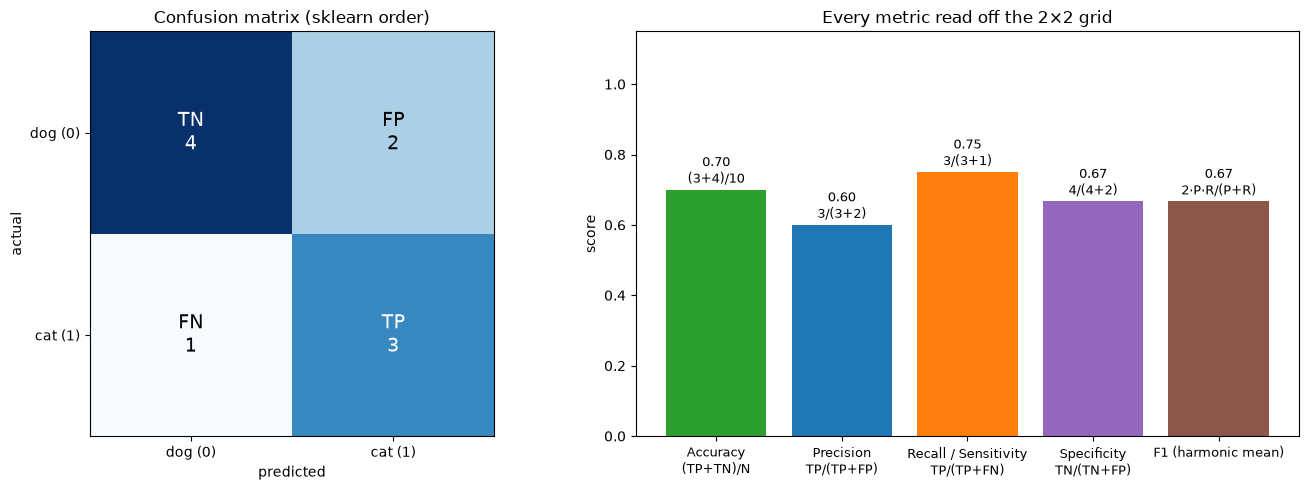

TP=3 FP=2 FN=1 TN=4  ->  acc=70%  prec=60%  recall=75%  spec=67%  F1=66.67%


In [16]:
# Aligned with the slides: 4 cats (+) and 6 dogs (-). Same data as the cats/dogs cells above.

import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# cats = positive class (1), dogs = negative class (0). 10 predictions:
y_true = np.array([1,1,1,1, 0,0,0,0,0, 0])   # 4 cats, 6 dogs
y_pred = np.array([1,1,1,0, 1,1,0,0,0,0])   # 3 cats right, 2 dogs mis-called cats, 1 cat missed
cm = confusion_matrix(y_true, y_pred)         # sklearn order: rows=actual, cols=predicted
tn, fp, fn, tp = cm.ravel()                   # ravel() order: [TN, FP, FN, TP]
N = len(y_true)

# Every metric is a count you can read off the grid above:
acc  = (tp + tn) / N                       # all correct / total
prec = tp / (tp + fp)                     # of predicted positives, how many truly positive
rec  = tp / (tp + fn)                     # of actual positives, how many we caught (sensitivity)
spec = tn / (tn + fp)                     # of actual negatives, how many we correctly left alone
f1   = 2 * prec * rec / (prec + rec)      # harmonic mean of precision & recall

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
labels = np.array([['TN','FP'],['FN','TP']])
ax[0].imshow(cm, cmap='Blues')
ax[0].set_xticks([0,1]); ax[0].set_yticks([0,1])
ax[0].set_xticklabels(['dog (0)','cat (1)']); ax[0].set_yticklabels(['dog (0)','cat (1)'])
ax[0].set_xlabel('predicted'); ax[0].set_ylabel('actual'); ax[0].set_title('Confusion matrix (sklearn order)')
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, f"{labels[i,j]}\n{cm[i,j]}", ha='center', va='center',
                   color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)

metrics = [
    ('Accuracy\n(TP+TN)/N',          acc,  '(3+4)/10'),
    ('Precision\nTP/(TP+FP)',         prec, '3/(3+2)'),
    ('Recall / Sensitivity\nTP/(TP+FN)', rec, '3/(3+1)'),
    ('Specificity\nTN/(TN+FP)',       spec, '4/(4+2)'),
    ('F1 (harmonic mean)',            f1,   '2·P·R/(P+R)'),
]
xs = np.arange(len(metrics))
ax[1].bar(xs, [m[1] for m in metrics], color=['#2ca02c','#1f77b4','#ff7f0e','#9467bd','#8c564b'])
ax[1].set_xticks(xs); ax[1].set_xticklabels([m[0] for m in metrics], fontsize=9)
ax[1].set_ylim(0, 1.15); ax[1].set_ylabel('score'); ax[1].set_title('Every metric read off the 2×2 grid')
for x, m in zip(xs, metrics):
    ax[1].text(x, m[1]+0.02, f'{m[1]:.2f}\n{m[2]}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

print(f"TP={tp} FP={fp} FN={fn} TN={tn}  ->  "
      f"acc={acc:.0%}  prec={prec:.0%}  recall={rec:.0%}  spec={spec:.0%}  F1={f1:.2%}")


### 🧠 Quick quiz

1. The dumb classifier at the top got 20 % accuracy but **100 % recall**. How can a terrible model have perfect recall?
2. Swap the positive class from **cat** to **dog**. Which two metrics swap values, and which one is genuinely invariant? (Hint: which metric counts all four cells?)
3. A model predicts *positive* for every single row. What is its **precision**, and why is **specificity** zero (not undefined)?
4. **(Exam-style justify)** On a heavily imbalanced spam dataset (95 % ham, 5 % spam), a model that labels everything "ham" scores 95 % accuracy. Name the *two* metrics that immediately expose it as useless, and state which one a spam filter should actually optimise and why.

<details><summary>Answers (click to reveal)</summary>

1. Recall $= \frac{TP}{TP+FN}$ only counts *real positives the model caught*. A model that predicts positive for *everything* sets $FN=0$, so recall $= 100\%$ – it catches every real positive by shouting positive at all of them. The cost (a flood of false alarms) is invisible to recall; only precision sees it.
2. **Recall and specificity swap** (each is the other class's "catch rate"). **Accuracy is invariant** – it counts all four cells ($TP+TN$ over everyone), and relabelling just renames which cell is $TP$ vs $TN$ without changing the total. (Precision and F1 *change* to new values, they do not simply swap – see the by-hand check above.)
3. Precision $= \frac{TP}{TP+FP}$ collapses toward the base positive rate (huge $FP$). Specificity $= \frac{TN}{TN+FP}$: predicting positive everywhere means $TN=0$, so specificity $= \frac{0}{0+FP} = 0$ – **defined but zero**, because the model never correctly identifies a negative.
4. **Recall $= 0\%$** (no spam caught: $TP=0$) and **precision is $0$ / undefined** (no positive predictions, so $TP+FP=0$). A spam filter should optimise **precision** – the costly error is a false positive (a real email filed as spam), so you want few false alarms even at the cost of letting some spam through. Accuracy hides both failures behind the 95 % ham majority.

</details>
